In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np

import os
import pandas as pd
import numpy as np

#from keras.layers.wrappers import Bidirectional

In [3]:
data=pd.read_excel('/content/drive/MyDrive/Math Task/Math entity Relationship/Emglish ME Relationship WO tokens.xlsx')
data.dropna()
data

,Unnamed: 0,Text,Entity1,Entity2,Relation
0,0,Adding one and two makes three.,one,two,addition
1,1,The factorial value of five is one hundred an...,five,one hundred and twenty,Factorial
2,5,Add one and three to four.,one,three,addition
3,6,Adding one to one makes two.,one,one,addition
4,7,Eleven and two add up to thirteen,Eleven,two,addition
...,...,...,...,...,...
3280,3424,We get one hundred and fifty-six when we add ...,One hundred and fifty six,one hundred,addition
3281,3425,We get one hundred and fifty-seven when we add...,One hundred and fifty seven,one hundred,addition
3282,3426,We get one hundred and fifty-eight when we ad...,One hundred and fifty eight,one hundred,addition
3283,3427,We get one hundred and sixty nine when we add...,One hundred and sixty nine,one hundred,addition


In [4]:
'''test=pd.read_csv('/content/drive/MyDrive/Math Task/Math entity Relationship/test_data.csv')
test.dropna()
test'''

"test=pd.read_csv('/content/drive/MyDrive/Math Task/Math entity Relationship/test_data.csv')\ntest.dropna()\ntest"

In [5]:
character_set_not =  ['\n', '!', '"', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '=', '?',
                      '[', '\\', ']', '{', '}', '\xa0', '¬', '´', '·', '।', '\u09e4', '৷', '\u200d', '–', '—', '‘', '’', '“', '”', '•']

In [6]:
def tokenize(s):
    for i in character_set_not:
        s =  s.replace(i, '')
    s=s.lower()
    return  s

In [7]:
'''train['Text']=train['Text'].map(tokenize)
train'''

"train['Text']=train['Text'].map(tokenize)\ntrain"

In [8]:
data['Text']=data['Text'].map(tokenize)
data

,Unnamed: 0,Text,Entity1,Entity2,Relation
0,0,adding one and two makes three,one,two,addition
1,1,the factorial value of five is one hundred an...,five,one hundred and twenty,Factorial
2,5,add one and three to four,one,three,addition
3,6,adding one to one makes two,one,one,addition
4,7,eleven and two add up to thirteen,Eleven,two,addition
...,...,...,...,...,...
3280,3424,we get one hundred and fiftysix when we add o...,One hundred and fifty six,one hundred,addition
3281,3425,we get one hundred and fiftyseven when we add ...,One hundred and fifty seven,one hundred,addition
3282,3426,we get one hundred and fiftyeight when we add...,One hundred and fifty eight,one hundred,addition
3283,3427,we get one hundred and sixty nine when we add...,One hundred and sixty nine,one hundred,addition


In [9]:
labels = [0,1,2,3,4,5]
labels

[0, 1, 2, 3, 4, 5]

In [10]:
data.columns

Index(['Unnamed: 0', 'Text', ' Entity1', ' Entity2', ' Relation'], dtype='object')

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load your dataset and split it into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(data['Text'],data[' Relation'], test_size=0.2, random_state=42)

'''X_train= train['Text']
X_val= test['Text']
y_val= test['Relation']
y_train= train['Relation']'''

"X_train= train['Text']\nX_val= test['Text']\ny_val= test['Relation']\ny_train= train['Relation']"

In [12]:
from transformers import BertTokenizerFast

# Load Tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Define custom tokens to add
#new_tokens = ["$","#"]

# Add the tokens to the tokenizer vocabulary
#num_added_toks = tokenizer.add_tokens(new_tokens)

# Tokenizing
train_encodings = tokenizer(list(X_train), truncation=True, padding=True)
test_encodings = tokenizer(list(X_val), truncation=True, padding=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_val)
y_train

array([0, 3, 5, ..., 3, 5, 4])

In [14]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(labels), from_pt=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
# Instead of using model.compute_loss, try using a standard loss like 'sparse_categorical_crossentropy'
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5, epsilon=1e-08, clipnorm=1.0)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric= tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])
model.summary()

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  4614      
                                                                 
Total params: 109486854 (417.66 MB)
Trainable params: 109486854 (417.66 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings),np.array(y_train)))
test_dataset  = tf.data.Dataset.from_tensor_slices((dict(test_encodings),np.array(y_test)))

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
#es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=2)

model.fit(
    train_dataset.batch(12),
    epochs=40,
    batch_size=12,
    validation_data=test_dataset.batch(12),
    #callbacks=[es
)

Epoch 1/40
219/219 [==============================] - 142s 255ms/step - loss: 0.5386 - accuracy: 0.8394 - val_loss: 0.1159 - val_accuracy: 0.9543
Epoch 2/40
219/219 [==============================] - 43s 197ms/step - loss: 0.0566 - accuracy: 0.9836 - val_loss: 0.0612 - val_accuracy: 0.9802
Epoch 3/40
219/219 [==============================] - 40s 184ms/step - loss: 0.0184 - accuracy: 0.9966 - val_loss: 0.0302 - val_accuracy: 0.9939
Epoch 4/40
219/219 [==============================] - 41s 185ms/step - loss: 0.0079 - accuracy: 0.9985 - val_loss: 0.0314 - val_accuracy: 0.9924
Epoch 5/40
219/219 [==============================] - 40s 184ms/step - loss: 0.0077 - accuracy: 0.9989 - val_loss: 0.0344 - val_accuracy: 0.9924
Epoch 6/40
219/219 [==============================] - 40s 185ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0181 - val_accuracy: 0.9954
Epoch 7/40
219/219 [==============================] - 40s 185ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.0211 - val_a

In [18]:
tloss=model.history.history['loss']
vloss=model.history.history['val_loss']

In [20]:
tloss

[0.5386316180229187,
 0.05658649280667305,
 0.0183879267424345,
 0.007908379659056664,
 0.007708111312240362,
 0.0030141184106469154,
 0.0014972592471167445,
 0.0011345766251906753,
 0.000909936148673296,
 0.0007397605804726481,
 0.0006139837205410004,
 0.0005138368578627706,
 0.0004365860077086836,
 0.00037461737520061433,
 0.00032001821091398597,
 0.00027790950844064355,
 0.0002413444162812084,
 0.0002105921448674053,
 0.00018489555804990232,
 0.00016167711874004453,
 0.00014322165225166827,
 0.0001264220045413822,
 0.00011180622823303565,
 9.832413343247026e-05,
 8.759592310525477e-05,
 7.703973824391142e-05,
 6.884782487759367e-05,
 6.128711538622156e-05,
 5.481131302076392e-05,
 4.87510442326311e-05,
 4.327377610024996e-05,
 3.8731526728952304e-05,
 3.44915060850326e-05,
 3.090995232923888e-05,
 2.765240969893057e-05,
 2.451924046908971e-05,
 2.197394314862322e-05,
 1.982146204682067e-05,
 1.767898356774822e-05,
 1.5824260117369704e-05]

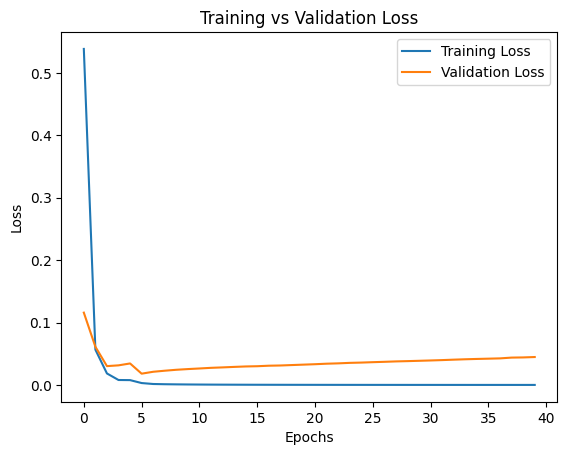

In [21]:
import matplotlib.pyplot as plt

# Extract losses
tloss = model.history.history['loss']
vloss = model.history.history['val_loss']

# Plot
plt.figure()
plt.plot(tloss, label='Training Loss')
plt.plot(vloss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/Math Task/Math entity Relationship/Figures/lossoverepoch.pdf')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming you have your test_dataset and true labels ready
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), np.array(y_val))).batch(12)

# Get the true labels and ensure they are numerical using label encoding
y_true = label_encoder.transform(y_val) # Use label_encoder to transform y_val into numerical labels

# Make predictions on the test dataset
y_pred = model.predict(test_dataset).logits
y_pred = np.argmax(y_pred, axis=1)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", conf_matrix)


55/55 [==============================] - 7s 50ms/step
Confusion Matrix:
 [[ 70   0   0   0   0   0]
 [  0  96   5   5   1   0]
 [  0   0  96   0   0   0]
 [  0   0   0 114   2   0]
 [  0   0   0   2 103   0]
 [  0   0   0   0   0 163]]


In [ ]:
classes=['Factorial','Addition','Substruction','Multiplication','Division','Squar Root']

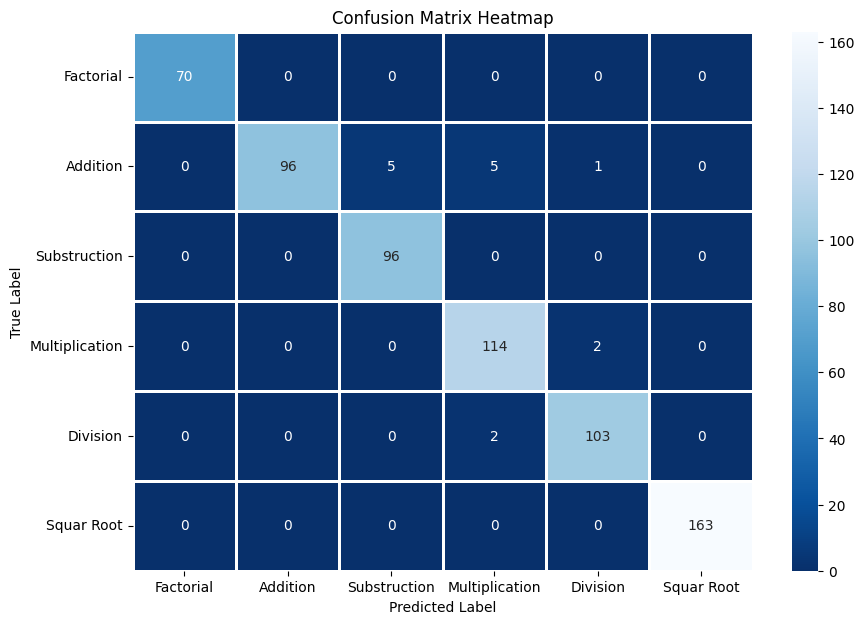

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ... (your existing code to calculate the confusion matrix) ...

# Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 7))  # Adjust figure size as needed
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues_r",
            xticklabels=classes,  # Use original labels for x-axis
            yticklabels=classes,linewidths=1)  # Use original labels for y-axis
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.savefig('/content/drive/MyDrive/Math Task/Math entity Relationship/Figures/confusionmatrix.pdf')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code to calculate y_true and y_pred) ...

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate precision, recall, and F1-score (macro-averaged)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")

Accuracy: 0.9772
Precision (macro): 0.9774
Recall (macro): 0.9768
F1-score (macro): 0.9765


In [ ]:
id2labels = model.config.id2label
model.config.id2label = {id : label_encoder.inverse_transform([id])[0]  for id, label in id2labels.items()}

label2ids = model.config.label2id
model.config.label2id = {label_encoder.inverse_transform([id])[0] : id   for id, label in id2labels.items()}

In [ ]:
!pip install shap

In [ ]:
import transformers
import shap

In [ ]:
pred = transformers.pipeline("text-classification", model=model, tokenizer=tokenizer, device=0, return_all_scores=True)
explainer = shap.Explainer(pred)

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
ls=['[#] Eighteen [#] players of the Sri Lankan national cricket team have come to play in Bangladesh. Bangladesh team also has [$] eighteen [$] players. There are total thirty six players in two teams.' ,
'A man bought ten mangoes and divided them equally among [#] five [#] children. Each child  got [$] two [$] of mangoes.' ,
 ' A packet contains [#] two [#] chocolates. [$] How many chocolates are in eight [$] packets',
'The square root of [#] one hundred twenty one [#] is [$] eleven [$].',
'Subtracting [#] forty-six [#] from [$] one hundred [$] equals fifty-four.',
'The factorial value of [#] seven [#] is [$] five thousand and forty [$].'
]
ls=[tokenize(s) for s in ls]

In [ ]:
ls=[s.replace('#','').replace('$','').replace("  ",' ') for s in ls]
ls

[' eighteen players of the sri lankan national cricket team have come to play in bangladesh bangladesh team also has eighteen players there are total thirty six players in two teams',
 'a man bought ten mangoes and divided them equally among five children each child got two of mangoes',
 ' a packet contains two chocolates how many chocolates are in eight packets',
 'the square root of one hundred twenty one is eleven ',
 'subtracting fortysix from one hundred equals fiftyfour',
 'the factorial value of seven is five thousand and forty ']

In [ ]:
'''ls=[' We get  seventysix  when we add thirtythree and fortythree',
 ' The square root of five hundred four is twenty two decimal four four',
 ' Factorial value of two is two.',
 ' We get  twenty two point five  when we divide forty five by two',
 'We get  fourteen  when subtracts twenty seven from forty one',
    'Six multiplied by Two is equals twelve.']
ls=[tokenize(s) for s in ls]'''

"ls=[' We get  seventysix  when we add thirtythree and fortythree',\n ' The square root of five hundred four is twenty two decimal four four',\n ' Factorial value of two is two.',\n ' We get  twenty two point five  when we divide forty five by two',\n 'We get  fourteen  when subtracts twenty seven from forty one',\n    'Six multiplied by Two is equals twelve.']\nls=[tokenize(s) for s in ls]"

In [ ]:
shap_values = explainer(ls)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 3/6 [03:13<01:57, 39.09s/it]

  0%|          | 0/240 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  83%|████████▎ | 5/6 [04:12<00:32, 32.24s/it]

  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 6/6 [04:51<00:00, 34.30s/it]

  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer: 7it [05:29, 54.87s/it]


In [ ]:
classes=['Factorial','Addition','Substruction','Multiplication','Division','Squar Root']

In [ ]:
shap_values.output_names=classes
shap_values.output_names

['Factorial',
 'Addition',
 'Substruction',
 'Multiplication',
 'Division',
 'Squar Root']

In [ ]:
shap.plots.text(shap_values, display=True)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import matplotlib.pyplot as plt
from IPython.core.display import HTML
HTML(shap.plots.text(shap_values, display=True))
with open('/content/drive/MyDrive/Math Task/Math entity Relationship/Figures/shapfinal.html', 'w') as file:
     file.write(shap.plots.text(shap_values, display=False))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import matplotlib.pyplot as plt
from IPython.core.display import HTML
HTML(shap.plots.text(shap_values[:,:,classes[4]], display=True))
with open('shap classwisedivision.html', 'w') as file:
     file.write(shap.plots.text(shap_values[:,:,classes[4]], display=False))

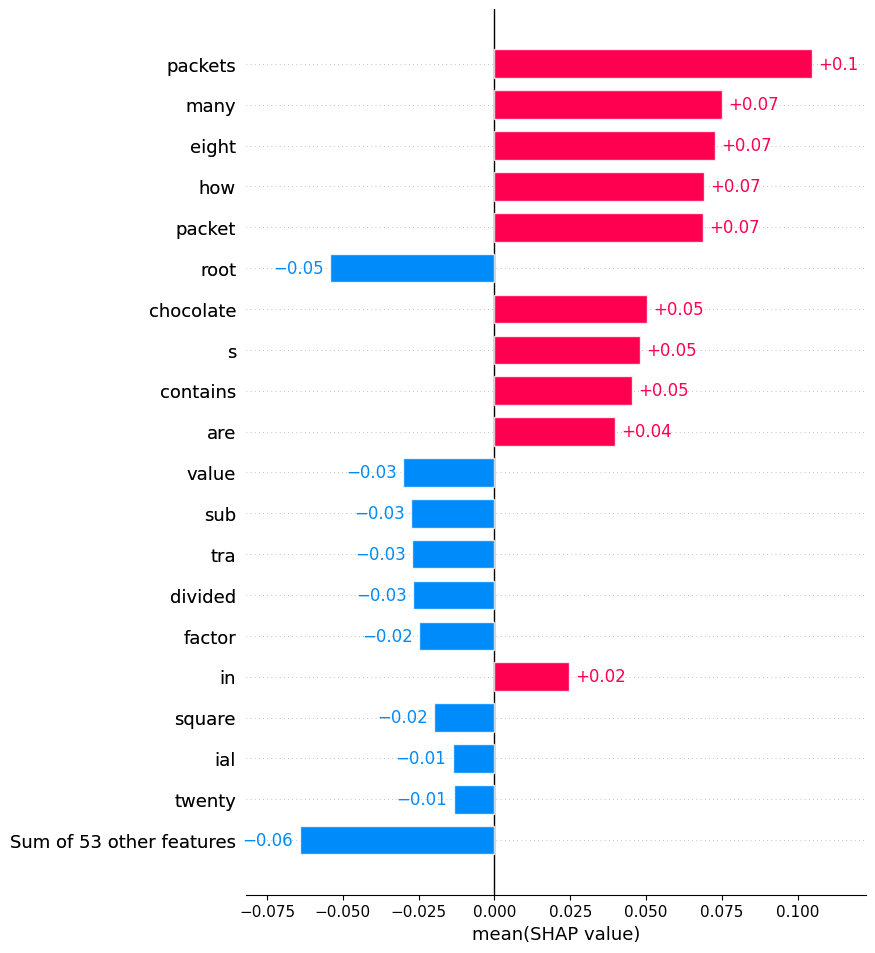

In [ ]:
shap.initjs
plt.figure(figsize=(9,13))
shap.plots.bar(shap_values[:,:,classes[3]].mean(0),max_display=20)
plt.savefig('/content/drive/MyDrive/Math Task/Math entity Relationship/Figures/shapvaluesbar.pdf')
plt.close()

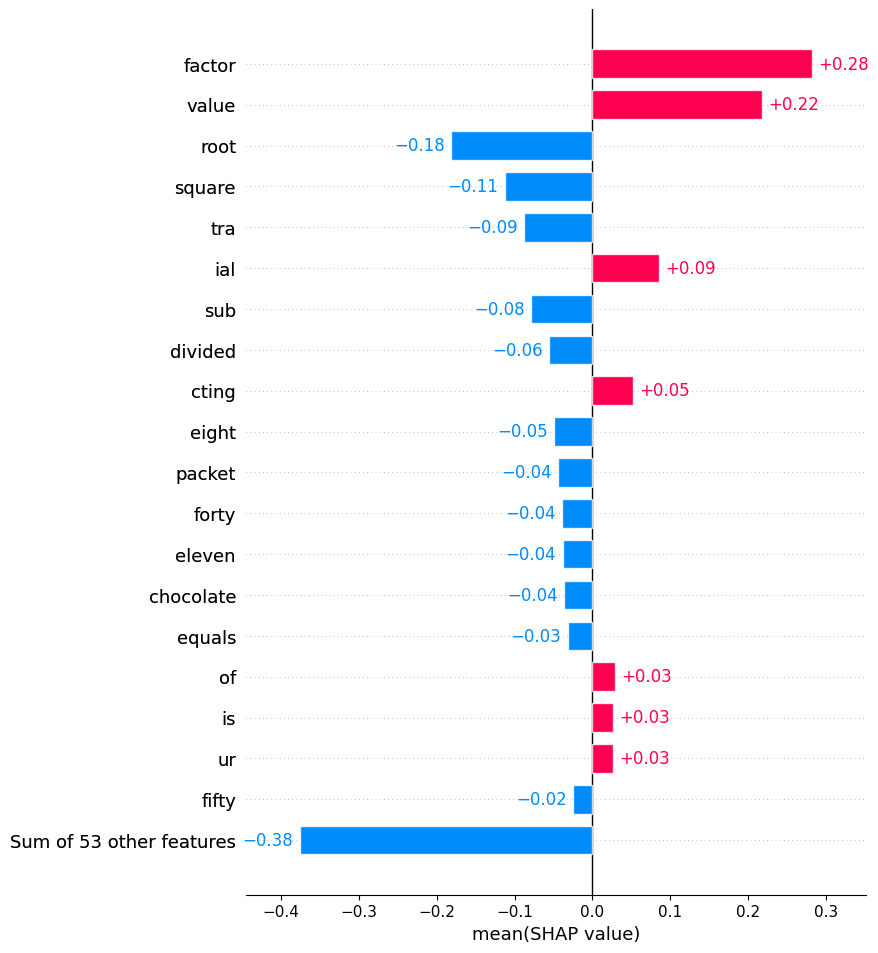

In [ ]:
shap.plots.bar(shap_values[:,:,classes[0]].mean(0),max_display=20)

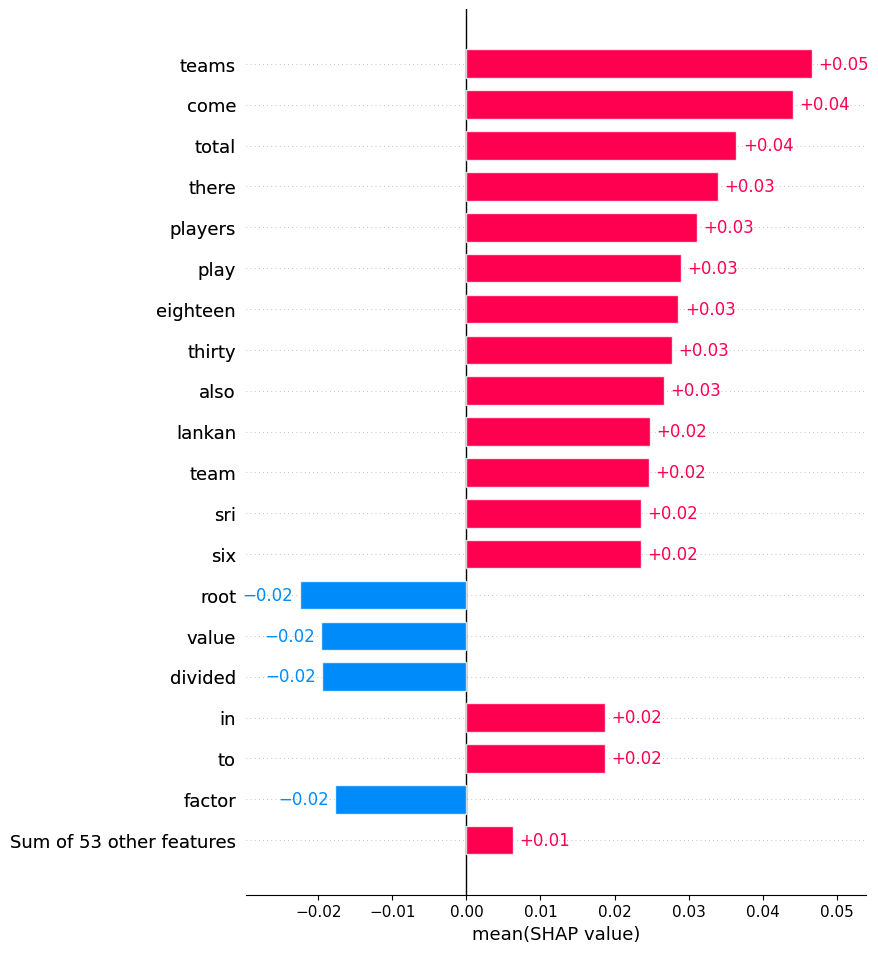

In [ ]:
shap.plots.bar(shap_values[:,:,classes[1]].mean(0),max_display=20)

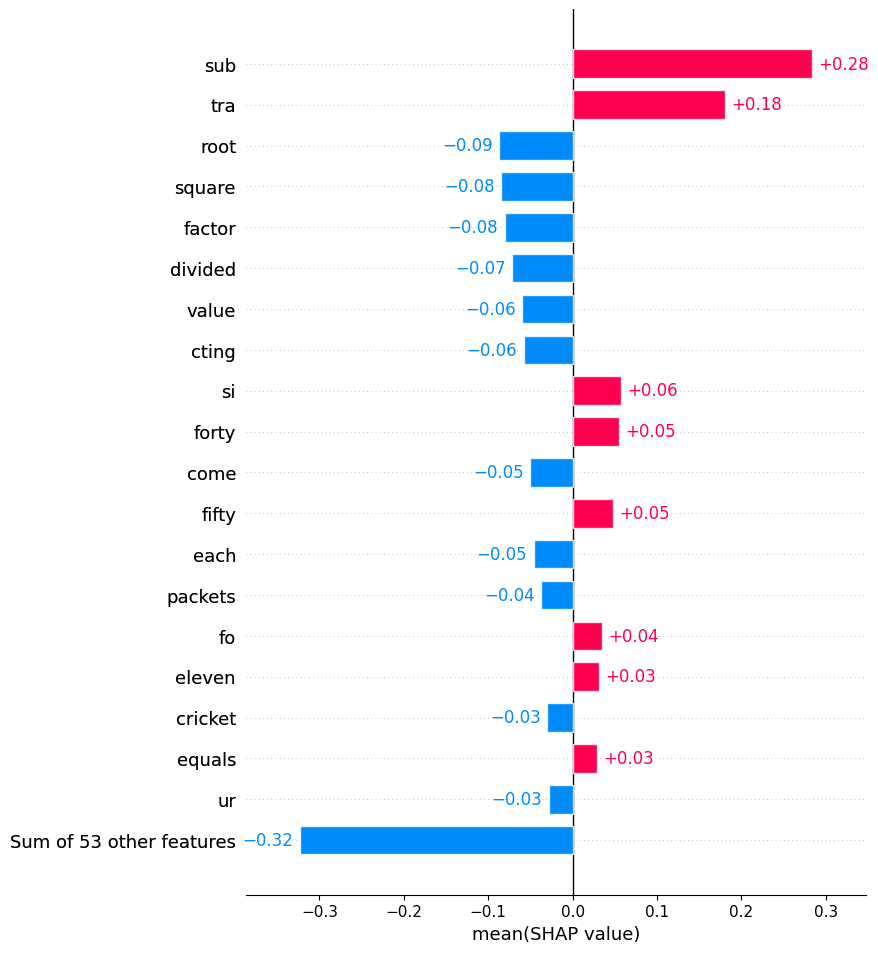

In [ ]:
shap.plots.bar(shap_values[:,:,classes[2]].mean(0),max_display=20)

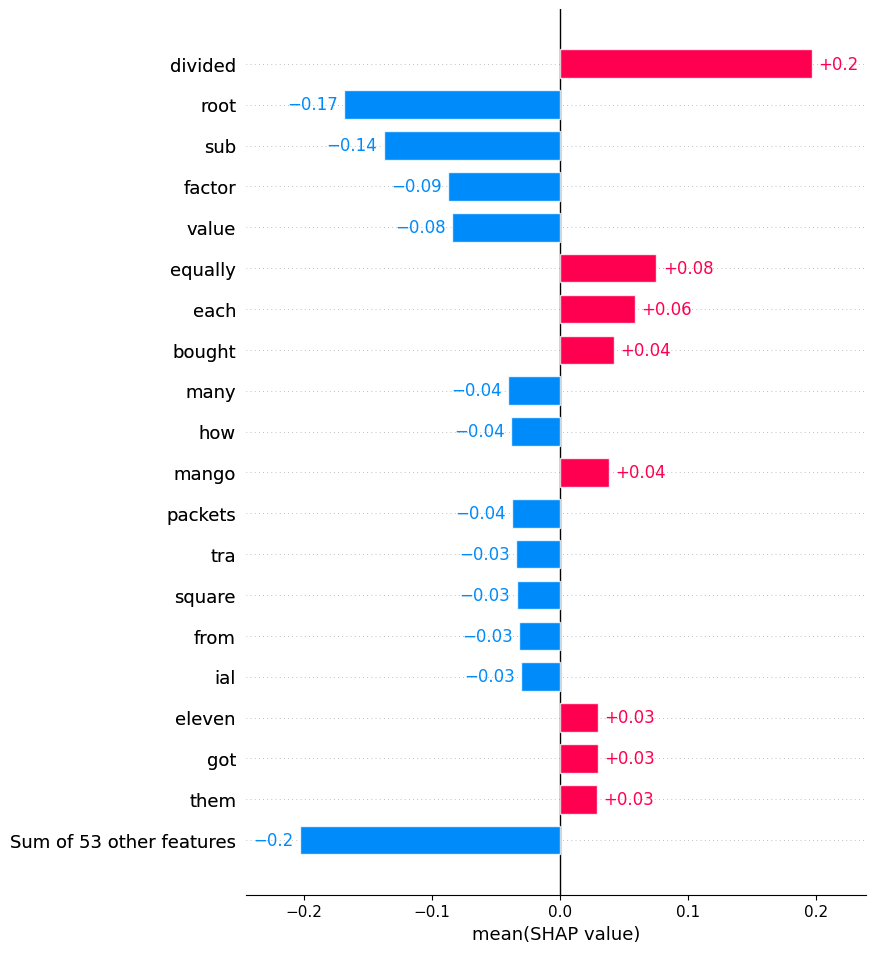

In [ ]:
shap.plots.bar(shap_values[:,:,classes[4]].mean(0),max_display=20)

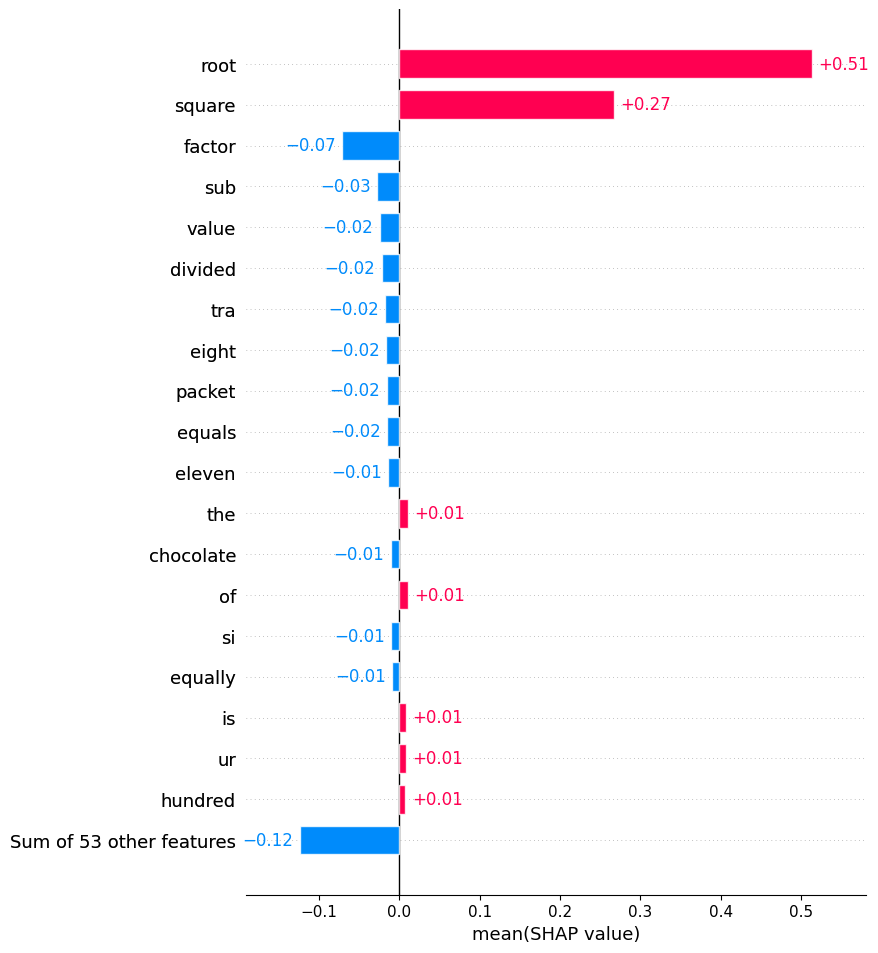

In [ ]:
shap.plots.bar(shap_values[:,:,classes[5]].mean(0),max_display=20)

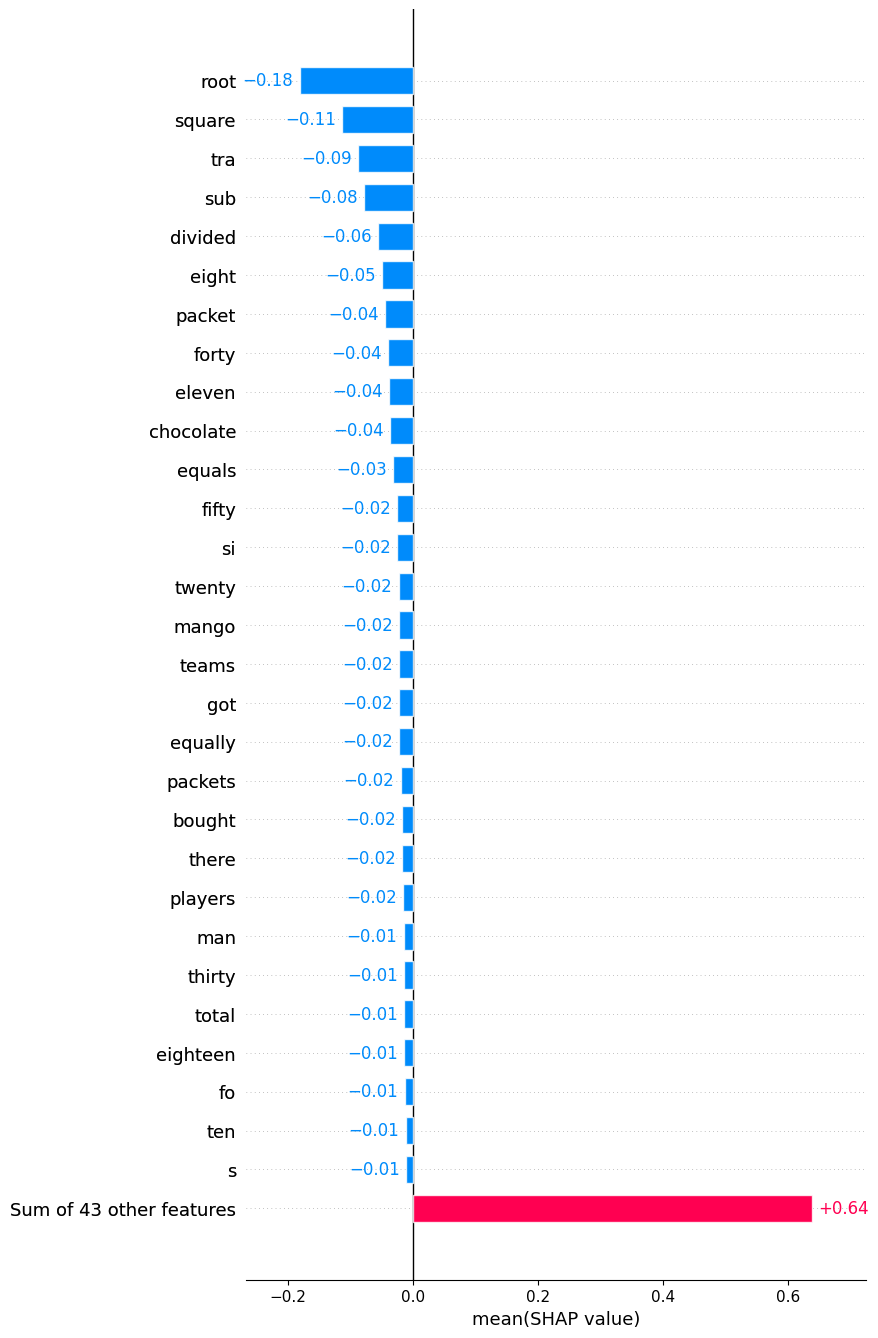

In [ ]:
# we can sort the bar chart in decending order
shap.plots.bar(shap_values[:, :, classes[0]].mean(0), order=shap.Explanation.argsort,max_display=30)

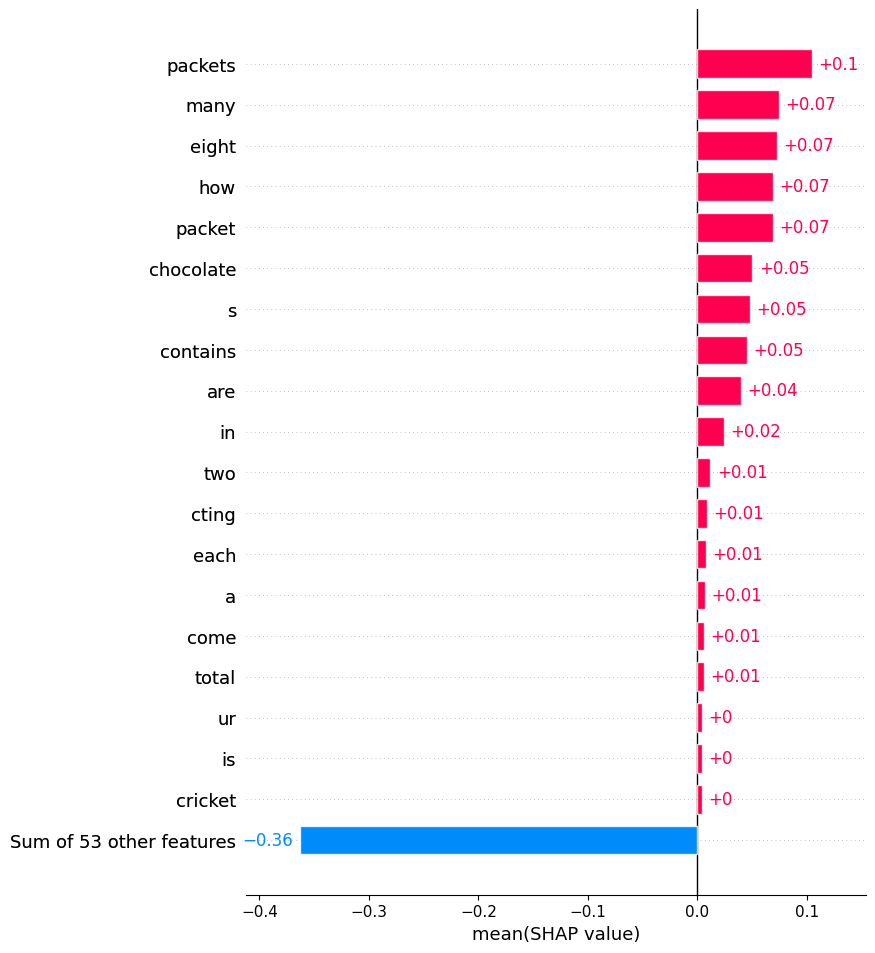

In [ ]:
shap.plots.bar(shap_values[:, :, classes[3]].mean(0), order=shap.Explanation.argsort.flip,max_display=20)

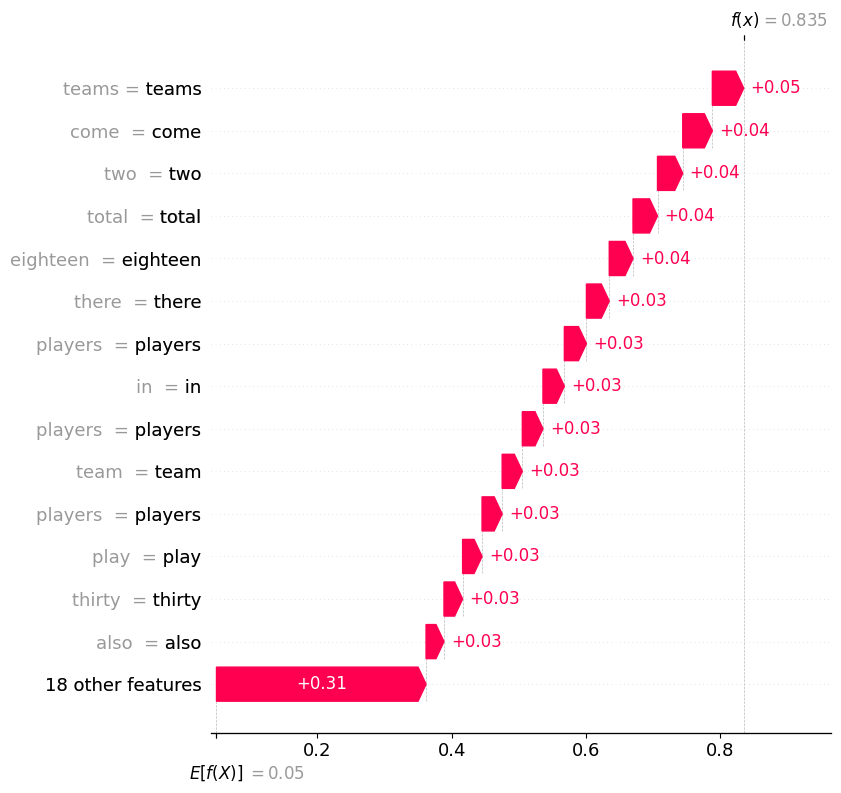

In [ ]:
shap.waterfall_plot(shap_values[0][:, classes[1]], max_display=15)

In [ ]:
logit_explainer = shap.Explainer(shap.models.TransformersPipeline(pred, rescale_to_logits=True))

logit_shap_values = logit_explainer(test["Text"][:3])
shap.plots.text(logit_shap_values)

NameError: name 'test' is not defined

In [ ]:
plt.rcParams["font.family"] = "Arial Unicode MS"  # Use a font that supports Bangla characters

# Plot the bar chart with Bangla feature names
shap.plots.bar(shap_values[:, :, '2'].mean(0))



# Display plot


In [ ]:
shap_values.feature_names